# Olist E-commerce · Análise Exploratória
## Vendas, entregas e satisfação dos clientes
Autor:**João Victor Azevedo Porto**

Etapa 03 · **Análise Exploratória**

### Pergunta central
**Como os atrasos nas entregas se relacionam com as avaliações dos clientes?**

A descoberta identificou problemas de tipos, ausência de informações e risco de duplicação nas junções. A limpeza produziu uma base com uma linha por pedido, critérios de elegibilidade e registros de qualidade. Agora, usamos essa base para contextualizar as vendas e investigar a experiência de entrega.

O percurso conecta cinco perguntas:

*  Qual é a dimensão do negócio observado
*  Como as vendas variam no tempo
*  Como as entregas se comportam
*  Onde os atrasos se concentram
*  Como os atrasos se associam as notas

**Escopo:** análise descritiva do conjunto histórico Olist. Valor de mercadorias não é lucro nem receita líquida da plataforma. Associações não demonstram causalidade.

**Estado desta entrega:** notebook preparado para executar sobre o resultado real da etapa 02. Nenhum número ou gráfico Olist foi inventado ou pré-preenchido. As interpretações quantitativas e o resumo executivo são gerados ao executar as células.

**Validação desta versão:** cálculos e gráficos testados com dados sintéticos em três cenários: dois grupos de entrega, ausência de avaliações e apenas um grupo. A leitura Parquet e a execução completa com o conjunto real ainda devem ser verificadas no Colab.


## 1. Preparação e reprodução

No Colab, abra o painel **Arquivos** à esquerda e arraste o ZIP gerado na limpeza (`olist_cleaning_output.zip`) ou apenas `orders_analysis.parquet`. Não é necessário montar o Drive nem usar `files.upload()`.

Se a limpeza já foi executada no mesmo ambiente, a base é localizada automaticamente. No projeto local, o caminho esperado é `data/processed/analytical/orders_analysis.parquet`. Em caso de múltiplas versões, informe `INPUT_PATH` explicitamente para evitar analisar uma cópia errada.

In [1]:
%pip install -q pandas numpy matplotlib pyarrow

from pathlib import Path
from io import BytesIO
from zipfile import ZipFile
import hashlib
import json
import shutil
import platform
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from IPython.display import display, Markdown

# Ajustes visuais comuns a todos os gráficos.
COLORS = {"main": "#186A8B", "late": "#D66A46", "muted": "#7D8996", "light": "#E9EFF3"}
plt.rcParams.update({
    "figure.figsize": (11, 5), "figure.dpi": 120, "savefig.dpi": 180,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11,
    "font.family": "DejaVu Sans", "axes.axisbelow": True,
})
pd.set_option("display.max_columns", 35)
pd.set_option("display.max_rows", 30)
BASE = Path("/content") if Path("/content").exists() else Path.cwd()
OUTPUT = BASE / "olist_eda_output"
for folder in ["images", "tables"]:
    (OUTPUT / folder).mkdir(parents=True, exist_ok=True)
MIN_UF_ORDERS = 100  # Regra de apresentação, não garantia de representatividade.
MIN_STRATUM_GROUP = 20  # Mínimo por grupo nas comparações dentro de UF.

figures = []
tables = {}
findings = []

def br(value, decimals=0):
    if pd.isna(value):
        return "não disponível"
    return f"{value:,.{decimals}f}".replace(",", "X").replace(".", ",").replace("X", ".")

def insight(text):
    findings.append(text)
    display(Markdown(text))

def save_plot(fig, name, note):
    fig.text(0.01, 0.01, note, fontsize=8, color="#53616D", wrap=True)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    fig.savefig(OUTPUT / "images" / f"{name}.png", bbox_inches="tight")
    figures.append(name)
    plt.show()
    plt.close(fig)

print("pandas:", pd.__version__)

pandas: 2.2.3


In [4]:
INPUT_PATH = "/content/olist_cleaning_output.zip"

if INPUT_PATH:
    source = Path(INPUT_PATH)
else:
    options = [
        BASE / "orders_analysis.parquet",
        BASE / "olist_cleaning_output" / "analytical" / "orders_analysis.parquet",
        BASE / "data" / "processed" / "analytical" / "orders_analysis.parquet",
        BASE.parent / "data" / "processed" / "analytical" / "orders_analysis.parquet",
        BASE / "olist_cleaning_output.zip",
    ]
    available = list(dict.fromkeys(p.resolve() for p in options if p.exists()))
    if len(available) != 1:
        raise FileNotFoundError(
            f"Foram encontradas {len(available)} entradas: {available}. "
            "Arraste o ZIP ou Parquet para o painel Arquivos do Colab e defina INPUT_PATH."
        )
    source = available[0]

cleaning_manifest = None
if source.suffix.lower() == ".zip":
    with ZipFile(source) as z:
        matches = [name for name in z.namelist() if name.endswith("analytical/orders_analysis.parquet")]
        if len(matches) != 1:
            raise ValueError("O ZIP deve conter exatamente uma base analytical/orders_analysis.parquet.")
        payload = z.read(matches[0])
        manifests = [name for name in z.namelist() if name.endswith("manifest.json")]
        if len(manifests) == 1:
            cleaning_manifest = json.loads(z.read(manifests[0]))
else:
    if source.suffix.lower() != ".parquet":
        raise ValueError("Use o ZIP da limpeza ou orders_analysis.parquet.")
    payload = source.read_bytes()
    companion = source.parent.parent / "manifest.json"
    if companion.exists():
        cleaning_manifest = json.loads(companion.read_text())

orders = pd.read_parquet(BytesIO(payload))
source_hash = hashlib.sha256(payload).hexdigest()
print(f"Base carregada: {len(orders):,} pedidos e {len(orders.columns)} colunas.")

Base carregada: 99,441 pedidos e 35 colunas.


## 2. Contrato da base e recortes de análise

Verificamos a unidade de cada linha e os tipos antes de calcular indicadores. As flags herdadas da limpeza definem três recortes diferentes:

| Recorte | Uso | Denominador |
|---|---|---|
| Vendas entregues | Volume, valor de mercadorias e ticket | Pedidos com `eligible_sales_analysis = True` |
| Entregas elegíveis | Tempo e taxa de atraso | Pedidos com `eligible_delivery_analysis = True` |
| Entregas com avaliação | Relação entre atraso e nota | Pedidos com `eligible_delivery_review_analysis = True` |

Cancelados e pedidos sem informações necessárias não entram nesses indicadores, mas permanecem no panorama de status. Uma nota por pedido foi selecionada na limpeza; a quantidade de avaliações originais continua em `review_count`.

**Definições:** ticket = soma de mercadorias ÷ pedidos elegíveis; atraso = entrega em dia posterior à previsão; nota baixa = 1 ou 2. O frete é mostrado separadamente. Nenhum ausente é transformado em zero para completar métricas.

In [5]:
required = [
    "order_id", "customer_unique_id", "customer_state", "order_status",
    "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date",
    "merchandise_cents", "freight_cents", "item_count", "review_count", "review_score",
    "delivery_days", "delay_days", "is_late", "eligible_sales_analysis",
    "eligible_delivery_analysis", "eligible_delivery_review_analysis",
]
missing = sorted(set(required) - set(orders.columns))
if missing:
    raise ValueError(f"Reexecute a limpeza: faltam colunas {missing}")
assert orders["order_id"].notna().all() and orders["order_id"].is_unique, "Esperada uma linha por pedido."
assert len(orders) > 0, "Base vazia."
for col in ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]:
    assert pd.api.types.is_datetime64_any_dtype(orders[col]), f"Tipo de data incorreto: {col}"
for col in ["eligible_sales_analysis", "eligible_delivery_analysis", "eligible_delivery_review_analysis", "is_late"]:
    assert pd.api.types.is_bool_dtype(orders[col]), f"Flag precisa ser booleana: {col}"
for col in ["merchandise_cents", "freight_cents", "item_count", "review_count", "review_score", "delivery_days", "delay_days"]:
    assert pd.api.types.is_numeric_dtype(orders[col]), f"Tipo numérico incorreto: {col}"

sales = orders.loc[orders["eligible_sales_analysis"].fillna(False)].copy()
delivery = orders.loc[orders["eligible_delivery_analysis"].fillna(False)].copy()
rated = orders.loc[orders["eligible_delivery_review_analysis"].fillna(False)].copy()
assert not sales.empty and not delivery.empty, "Sem pedidos elegíveis para vendas ou entregas."
assert sales[["merchandise_cents", "order_purchase_timestamp"]].notna().all().all()
assert sales["order_status"].eq("delivered").all() and sales["merchandise_cents"].gt(0).all()
assert delivery[["is_late", "delivery_days", "delay_days"]].notna().all().all()
assert delivery["delivery_days"].ge(0).all()
assert delivery["is_late"].eq(delivery["delay_days"].gt(0)).all()
assert rated["order_id"].isin(delivery["order_id"]).all()
assert rated["review_score"].isin([1, 2, 3, 4, 5]).all()
assert orders["order_purchase_timestamp"].notna().any()

coverage = pd.DataFrame([
    {"recorte": name, "pedidos": len(df), "percentual_da_base": len(df) / len(orders) * 100}
    for name, df in [("Todos os pedidos", orders), ("Vendas entregues", sales),
                     ("Entregas elegíveis", delivery), ("Entregas com nota", rated)]
])
tables["01_cobertura"] = coverage
display(coverage.round(2))
status = orders["order_status"].fillna("nao_informado").value_counts().rename_axis("status").reset_index(name="pedidos")
status["percentual"] = status["pedidos"] / len(orders) * 100
tables["02_status"] = status
display(status.round(2))
insight(f"A base tem **{br(len(orders))} pedidos**. O recorte de entregas com nota cobre "
        f"**{br(len(rated) / len(orders) * 100, 1)}%** da base; as conclusões sobre satisfação se referem a esse grupo.")

,recorte,pedidos,percentual_da_base
0,Todos os pedidos,99441,100.00
1,Vendas entregues,96478,97.02
2,Entregas elegíveis,95097,95.63
3,Entregas com nota,94458,94.99


,status,pedidos,percentual
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.3
6,created,5,0.01
7,approved,2,0.0


A base tem **99.441 pedidos**. O recorte de entregas com nota cobre **95,0%** da base; as conclusões sobre satisfação se referem a esse grupo.

## 3. Dimensão das vendas observadas

O panorama estabelece a escala do recorte de pedidos entregues. Consumidores são contados por `customer_unique_id`, e itens pela soma de `item_count`. Não contamos cada registro de item como um pedido.

O total de mercadorias não inclui frete. Para frete, apresentamos o total **observado** e a cobertura, pois somar valores preenchidos não recupera o valor dos ausentes.

In [16]:
gmv = sales["merchandise_cents"].sum() / 100
ticket = gmv / len(sales)
freight_coverage = sales["freight_cents"].notna().mean() * 100
kpis = pd.DataFrame([
    {"indicador": "Pedidos de vendas entregues", "valor": len(sales), "unidade": "pedidos"},
    {"indicador": "Consumidores identificados", "valor": sales["customer_unique_id"].nunique(), "unidade": "consumidores"},
    {"indicador": "Valor de mercadorias", "valor": gmv, "unidade": "BRL"},
    {"indicador": "Ticket médio sem frete", "valor": ticket, "unidade": "BRL/pedido"},
    {"indicador": "Frete observado", "valor": sales["freight_cents"].sum(min_count=1) / 100, "unidade": "BRL"},
    {"indicador": "Cobertura do valor de frete", "valor": freight_coverage, "unidade": "% dos pedidos"},
])
tables["03_indicadores_vendas"] = kpis

kpis_display = kpis.copy()
kpis_display["valor"] = kpis_display.apply(
    lambda row: br(row["valor"], 2) if "BRL" in row["unidade"] or "%" in row["unidade"] else br(row["valor"], 0),
    axis=1
)
display(kpis_display)

insight(f"Nos **{br(len(sales))}** pedidos elegíveis de vendas entregues, o valor de mercadorias é {br(gmv, 2)} reais, com ticket médio de {br(ticket, 2)} reais sem frete.")

,indicador,valor,unidade
0,Pedidos de vendas entregues,96.478,pedidos
1,Consumidores identificados,93.358,consumidores
2,Valor de mercadorias,"13.221.498,11",BRL
3,Ticket médio sem frete,"137,04",BRL/pedido
4,Frete observado,"2.198.275,64",BRL
5,Cobertura do valor de frete,"100,00",% dos pedidos


Nos **96.478** pedidos elegíveis de vendas entregues, o valor de mercadorias é 13.221.498,11 reais, com ticket médio de 137,04 reais sem frete.

## 4. Evolução mensal: volume e valor

Agrupamos por mês da compra. O intervalo vem de todas as compras da base. Meses nas extremidades são marcados como borda da observação; não presumimos que sejam completos. Um mês sem vendas elegíveis aparece com zero, mas isso não comprova ausência de atividade fora do recorte.

O período final também pode ter pedidos que ainda não haviam sido entregues quando os dados foram coletados. Por isso, quedas no final não são interpretadas automaticamente como retração do negócio. O percentual de pedidos elegíveis em cada mês ajuda a revelar esse efeito. Não calculamos crescimento entre meses possivelmente incompletos nem atribuímos sazonalidade a poucos ciclos.

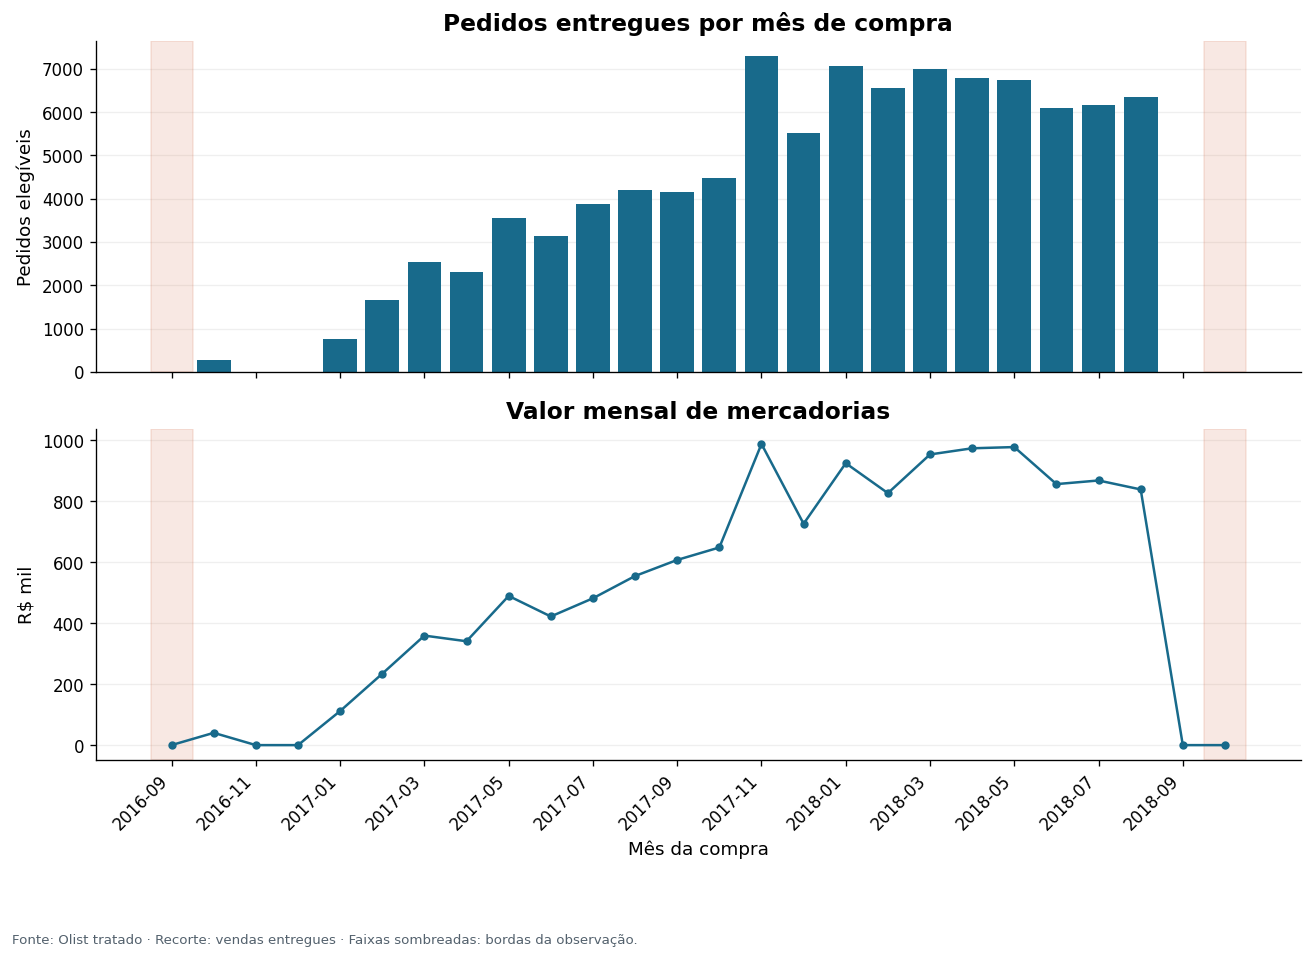

,pedidos,merchandise_cents,pedidos_na_base,valor_mercadorias_brl,ticket_brl,percentual_elegivel,borda_observacao
mes_compra,,,,,,,
2018-05,6749,97754469,6873,977544.69,144.84,98.20,False
2018-06,6099,85607786,6167,856077.86,140.36,98.90,False
2018-07,6159,86795346,6292,867953.46,140.92,97.89,False
2018-08,6351,83857664,6512,838576.64,132.04,97.53,False
2018-09,0,0,16,0.0,<NA>,0.00,False
2018-10,0,0,4,0.0,<NA>,0.00,True


O maior volume observado no recorte ocorreu em **2017-11**, com **7.289 pedidos**. O gráfico descreve a janela disponível; não demonstra uma tendência sustentável nem uma causa para o pico.

In [17]:
sales["purchase_month"] = sales["order_purchase_timestamp"].dt.to_period("M")
all_month = orders["order_purchase_timestamp"].dropna().dt.to_period("M")
month_index = pd.period_range(all_month.min(), all_month.max(), freq="M")
monthly = sales.groupby("purchase_month").agg(
    pedidos=("order_id", "size"), merchandise_cents=("merchandise_cents", "sum")
).reindex(month_index, fill_value=0)
monthly.index.name = "mes_compra"
monthly["pedidos_na_base"] = all_month.value_counts().reindex(month_index, fill_value=0)
monthly["valor_mercadorias_brl"] = monthly["merchandise_cents"] / 100
monthly["ticket_brl"] = monthly["valor_mercadorias_brl"] / monthly["pedidos"].replace(0, np.nan)
monthly["percentual_elegivel"] = monthly["pedidos"] / monthly["pedidos_na_base"].replace(0, np.nan) * 100
monthly["borda_observacao"] = monthly.index.isin([month_index[0], month_index[-1]])
tables["04_evolucao_mensal"] = monthly.reset_index()
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
x = np.arange(len(monthly))
axes[0].bar(x, monthly["pedidos"].to_numpy(dtype=float), color=COLORS["main"])
axes[0].set(title="Pedidos entregues por mês de compra", ylabel="Pedidos elegíveis")
axes[1].plot(x, monthly["valor_mercadorias_brl"].to_numpy(dtype=float) / 1000,
             marker="o", markersize=4, color=COLORS["main"])
axes[1].set(title="Valor mensal de mercadorias", ylabel="R$ mil", xlabel="Mês da compra")
for ax in axes:
    for edge in sorted(set([0, len(monthly) - 1])):
        ax.axvspan(edge - 0.5, edge + 0.5, color=COLORS["late"], alpha=0.15)
    ax.grid(axis="y", alpha=0.2)
step = max(1, len(monthly) // 12)
axes[1].set_xticks(x[::step], monthly.index.astype(str)[::step], rotation=45, ha="right")
save_plot(fig, "01_evolucao_mensal", "Fonte: Olist tratado · Recorte: vendas entregues · Faixas sombreadas: bordas da observação.")
display(monthly.tail(6).round(2))
peak = monthly["pedidos"].idxmax()
insight(f"O maior volume observado no recorte ocorreu em **{peak}**, com **{br(monthly.loc[peak, 'pedidos'])} pedidos**. "
        "O gráfico descreve a janela disponível; não demonstra uma tendência sustentável nem uma causa para o pico.")

## 5. Desempenho das entregas

Usamos mediana e percentil 90 para reduzir a dependência da média. O percentil 90 é o prazo dentro do qual ocorreram aproximadamente 90% das entregas elegíveis.

O histograma amplia até o percentil 99 para facilitar a leitura; o número de registros fora da janela é informado. As estatísticas e a taxa de atraso usam o recorte completo, sem cortar extremos.

,pedidos,atrasados,taxa_atraso_pct,mediana_dias,media_dias,p90_dias,maximo_dias
0,95097,6510,6.85,10.27,12.62,23.16,209.63


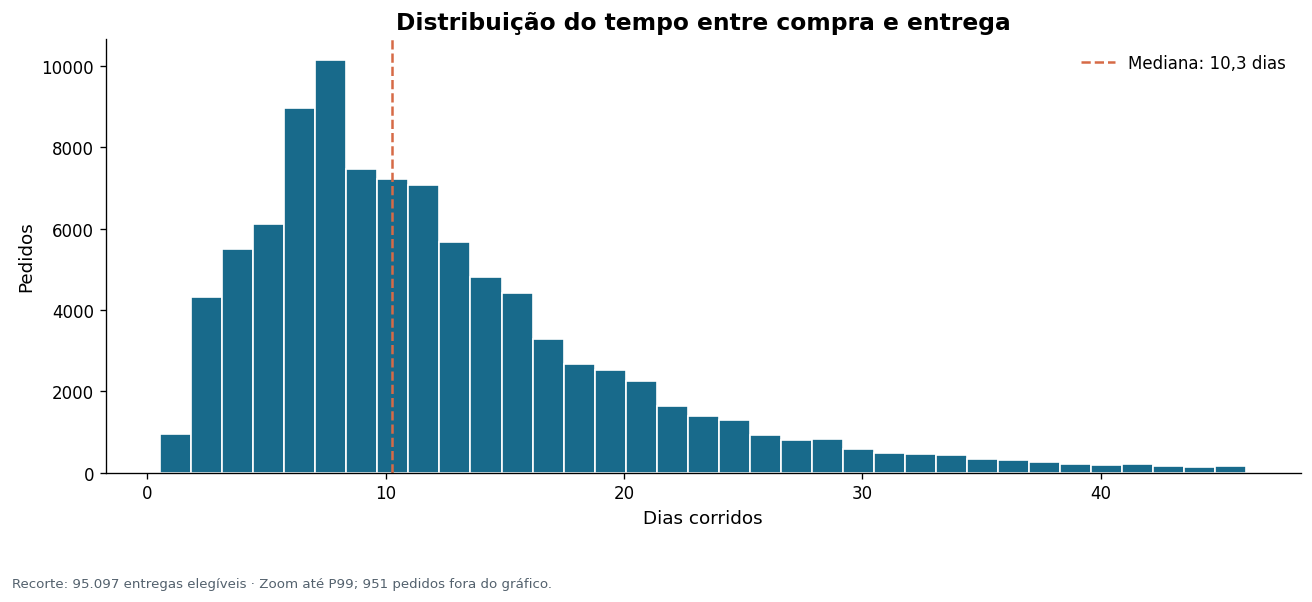

A mediana de entrega foi de **10,3 dias**, e o percentil 90 de **23,2 dias**. **6,8%** dos pedidos elegíveis chegaram após o dia previsto.

In [18]:
late_rate = delivery["is_late"].astype(bool).mean() * 100
median_days = delivery["delivery_days"].median()
p90_days = delivery["delivery_days"].quantile(0.90)
delivery_summary = pd.DataFrame([{
    "pedidos": len(delivery), "atrasados": int(delivery["is_late"].sum()),
    "taxa_atraso_pct": late_rate, "mediana_dias": median_days,
    "media_dias": delivery["delivery_days"].mean(), "p90_dias": p90_days,
    "maximo_dias": delivery["delivery_days"].max(),
}])
tables["05_resumo_entregas"] = delivery_summary
display(delivery_summary.round(2))
cut = float(delivery["delivery_days"].quantile(0.99))
shown = delivery.loc[delivery["delivery_days"].le(cut), "delivery_days"]
hidden = len(delivery) - len(shown)
fig, ax = plt.subplots()
ax.hist(shown.to_numpy(dtype=float), bins=35, color=COLORS["main"], edgecolor="white")
ax.axvline(median_days, color=COLORS["late"], linestyle="--", label=f"Mediana: {br(median_days, 1)} dias")
ax.set(title="Distribuição do tempo entre compra e entrega", xlabel="Dias corridos", ylabel="Pedidos")
ax.legend(frameon=False)
save_plot(fig, "02_tempo_entrega", f"Recorte: {br(len(delivery))} entregas elegíveis · Zoom até P99; {br(hidden)} pedidos fora do gráfico.")
insight(f"A mediana de entrega foi de **{br(median_days, 1)} dias**, e o percentil 90 de **{br(p90_days, 1)} dias**. "
        f"**{br(late_rate, 1)}%** dos pedidos elegíveis chegaram após o dia previsto.")

## 6. Atrasos por estado: taxa e volume juntos

A comparação usa a UF do cliente, não a do vendedor. Exibimos estados com pelo menos 100 entregas elegíveis (`MIN_UF_ORDERS`), além do tamanho da amostra. Todas as UFs, inclusive as excluídas do gráfico, permanecem na tabela exportada.

Uma taxa maior não comprova pior operação local: distância, transportadora, mix de vendedores, prazos prometidos e período podem variar. A linha nacional usa todas as entregas elegíveis, inclusive as de UF ausente.

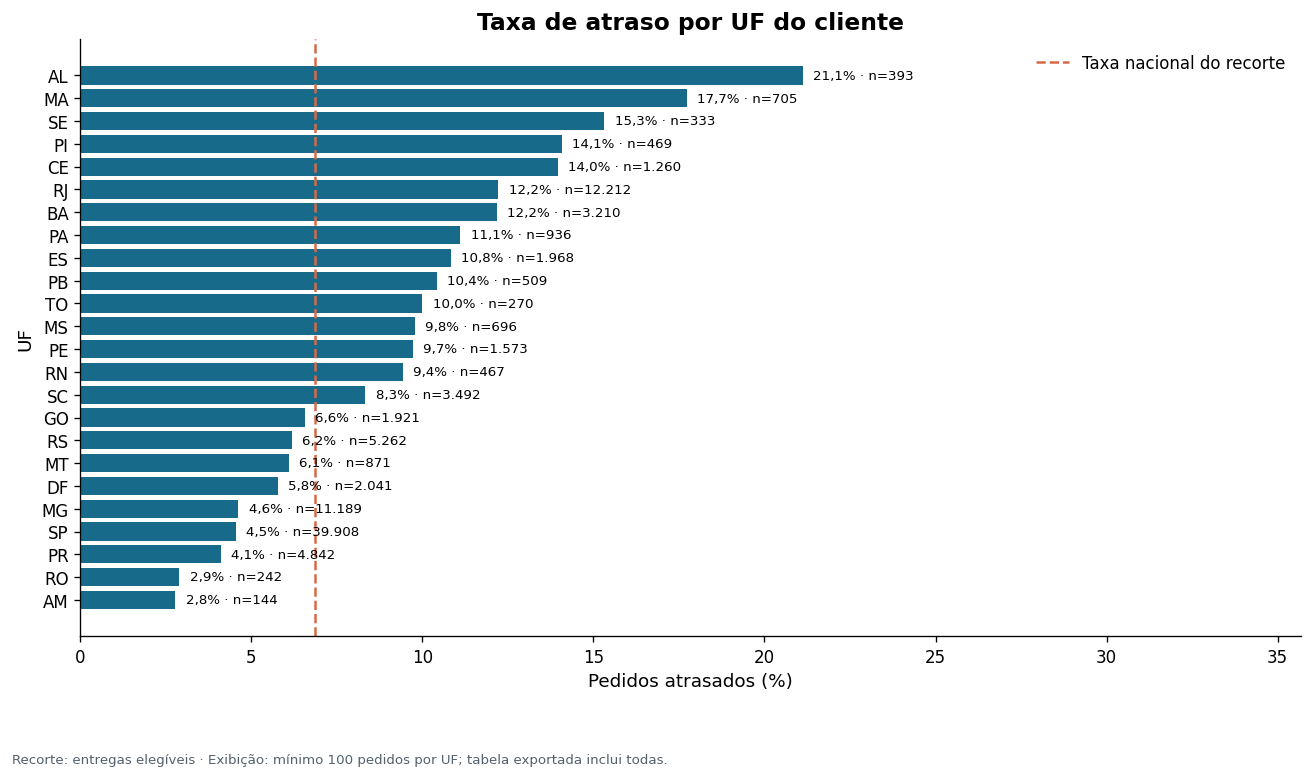

Entre as UFs que atendem ao mínimo de volume, **AL** tem a maior taxa observada: **21,1%**, em **393 pedidos**. Esse resultado orienta investigação, não uma conclusão causal sobre a região.

In [19]:
delivery["uf"] = delivery["customer_state"].fillna("Não informada")
uf = delivery.groupby("uf").agg(pedidos=("order_id", "size"), atrasados=("is_late", "sum"),
                                 mediana_dias=("delivery_days", "median"))
uf["taxa_atraso_pct"] = uf["atrasados"] / uf["pedidos"] * 100
uf["entra_no_grafico"] = uf["pedidos"].ge(MIN_UF_ORDERS) & uf.index.to_series().ne("Não informada")
tables["06_entregas_por_UF"] = uf.reset_index()
uf_plot = uf.loc[uf["entra_no_grafico"]].sort_values("taxa_atraso_pct")
if not uf_plot.empty:
    fig, ax = plt.subplots(figsize=(11, max(5, len(uf_plot) * 0.27)))
    ax.barh(uf_plot.index, uf_plot["taxa_atraso_pct"].to_numpy(dtype=float), color=COLORS["main"])
    for y, (_, row) in enumerate(uf_plot.iterrows()):
        ax.text(float(row["taxa_atraso_pct"]) + 0.3, y, f"{br(row['taxa_atraso_pct'], 1)}% · n={br(row['pedidos'])}", va="center", fontsize=8)
    ax.axvline(late_rate, color=COLORS["late"], linestyle="--", label="Taxa nacional do recorte")
    ax.set_xlim(0, max(1, float(uf_plot["taxa_atraso_pct"].max())) * 1.5 + 4)
    ax.set(title="Taxa de atraso por UF do cliente", xlabel="Pedidos atrasados (%)", ylabel="UF")
    ax.legend(frameon=False)
    save_plot(fig, "03_atrasos_UF", f"Recorte: entregas elegíveis · Exibição: mínimo {MIN_UF_ORDERS} pedidos por UF; tabela exportada inclui todas.")
    worst = uf_plot.index[-1]
    insight(f"Entre as UFs que atendem ao mínimo de volume, **{worst}** tem a maior taxa observada: "
            f"**{br(uf_plot.loc[worst, 'taxa_atraso_pct'], 1)}%**, em **{br(uf_plot.loc[worst, 'pedidos'])} pedidos**. "
            "Esse resultado orienta investigação, não uma conclusão causal sobre a região.")
else:
    insight("Nenhuma UF atende ao mínimo de volume. O ranking não foi produzido; consulte a tabela completa.")

## 7. Atraso e satisfação: distribuição de notas

A nota é ordinal: sua distribuição e a proporção de notas 1–2 complementam a média. A comparação usa pedidos com entrega elegível e nota válida. Ausência de avaliação não equivale a satisfação.

Primeiro verificamos a cobertura de notas entre atrasados e não atrasados. Diferenças de participação indicam possível viés de seleção. Avaliações podem ter sido respondidas antes da entrega; isso será examinado na análise de sensibilidade.

,entregas,com_nota,cobertura_pct
grupo,,,
No prazo,88587,88101,99.45
Atrasado,6510,6357,97.65


,pedidos,nota_media,nota_mediana,notas_baixas,notas_baixas_pct
grupo,,,,,
No prazo,88101,4.29,5.0,8159,9.26
Atrasado,6357,2.27,1.0,3972,62.48


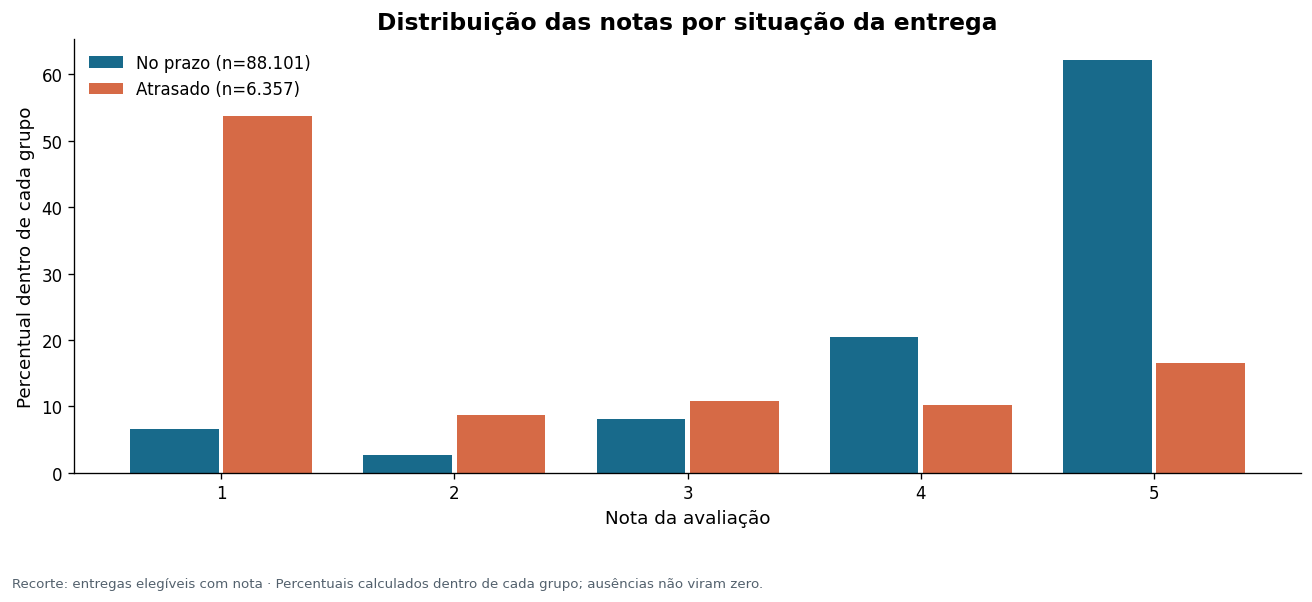

A proporção de notas 1–2 é **62,5% nos atrasados** e **9,3% nos pedidos no prazo**. Nos atrasados ela é maior; diferença absoluta de **53,2 pontos percentuais**. A comparação é descritiva e não isola o efeito do atraso.

In [20]:
GROUPS = ["No prazo", "Atrasado"]
delivery["grupo"] = np.where(delivery["is_late"].astype(bool), "Atrasado", "No prazo")
rated["grupo"] = np.where(rated["is_late"].astype(bool), "Atrasado", "No prazo")
rated["nota_baixa"] = rated["review_score"].le(2)
coverage_review = delivery.groupby("grupo").size().reindex(GROUPS, fill_value=0).rename("entregas").to_frame()
coverage_review["com_nota"] = rated.groupby("grupo").size().reindex(GROUPS, fill_value=0)
coverage_review["cobertura_pct"] = coverage_review["com_nota"] / coverage_review["entregas"].replace(0, np.nan) * 100
tables["07_cobertura_avaliacoes"] = coverage_review.reset_index()
display(coverage_review.round(2))

comparison = rated.groupby("grupo").agg(pedidos=("order_id", "size"), nota_media=("review_score", "mean"),
                                        nota_mediana=("review_score", "median"), notas_baixas=("nota_baixa", "sum")).reindex(GROUPS)
comparison["notas_baixas_pct"] = comparison["notas_baixas"] / comparison["pedidos"] * 100
tables["08_atraso_e_notas"] = comparison.reset_index()
display(comparison.round(2))
if not rated.empty:
    counts = pd.crosstab(rated["grupo"], rated["review_score"]).reindex(index=GROUPS, columns=[1,2,3,4,5], fill_value=0)
    percentages = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
    tables["09_distribuicao_notas_contagem"] = counts.reset_index()
    tables["10_distribuicao_notas_percentual"] = percentages.reset_index()
    fig, ax = plt.subplots()
    x = np.arange(5)
    for offset, group, color in [(-0.2, "No prazo", COLORS["main"]), (0.2, "Atrasado", COLORS["late"])]:
        ax.bar(x + offset, percentages.loc[group].to_numpy(dtype=float), width=0.38,
               label=f"{group} (n={br(counts.loc[group].sum())})", color=color)
    ax.set_xticks(x, [1,2,3,4,5])
    ax.set(title="Distribuição das notas por situação da entrega", xlabel="Nota da avaliação", ylabel="Percentual dentro de cada grupo")
    ax.legend(frameon=False)
    save_plot(fig, "04_notas_e_atraso", "Recorte: entregas elegíveis com nota · Percentuais calculados dentro de cada grupo; ausências não viram zero.")
if comparison["pedidos"].notna().all() and comparison["pedidos"].gt(0).all():
    difference = comparison.loc["Atrasado", "notas_baixas_pct"] - comparison.loc["No prazo", "notas_baixas_pct"]
    direction = "maior" if difference > 0 else "menor" if difference < 0 else "igual"
    insight(f"A proporção de notas 1–2 é **{br(comparison.loc['Atrasado', 'notas_baixas_pct'], 1)}% nos atrasados** e "
            f"**{br(comparison.loc['No prazo', 'notas_baixas_pct'], 1)}% nos pedidos no prazo**. "
            f"Nos atrasados ela é {direction}; diferença absoluta de **{br(abs(difference), 1)} pontos percentuais**. "
            "A comparação é descritiva e não isola o efeito do atraso.")
else:
    insight("Não há avaliações nos dois grupos para calcular a diferença entre atrasados e pedidos no prazo.")

## 8. Intensidade do atraso

Agrupamos pedidos em faixas de dias de atraso. Isso permite investigar se a experiência varia com atrasos mais longos, sem pressupor uma relação crescente.

A primeira faixa reúne entregas antecipadas e no dia previsto. A tabela apresenta a quantidade de pedidos por faixa; grupos pequenos podem produzir percentuais instáveis.

,pedidos,nota_media,notas_baixas,notas_baixas_pct
faixa_atraso,,,,
No prazo,88101,4.29,8159,9.26
1–3 dias,1842,3.29,594,32.25
4–7 dias,1741,2.1,1178,67.66
8–14 dias,1444,1.67,1157,80.12
15+ dias,1330,1.72,1043,78.42


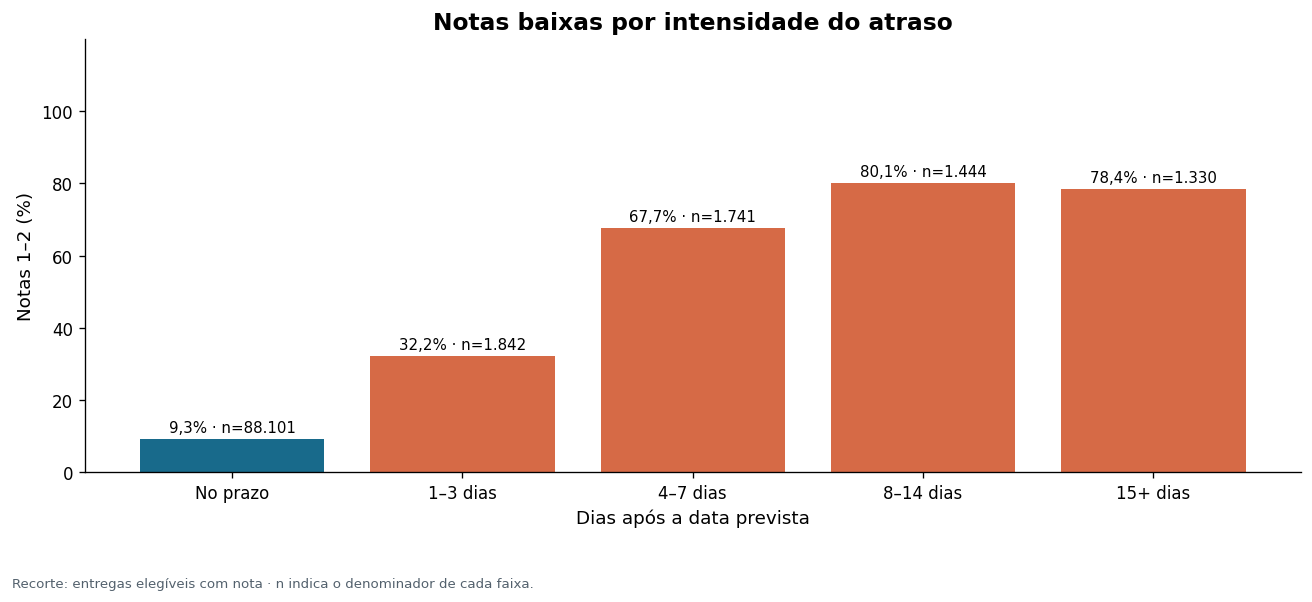

In [21]:
BANDS = ["No prazo", "1–3 dias", "4–7 dias", "8–14 dias", "15+ dias"]
rated["faixa_atraso"] = pd.cut(rated["delay_days"].astype(float),
    bins=[-np.inf,0,3,7,14,np.inf], labels=BANDS)
band = rated.groupby("faixa_atraso", observed=False).agg(
    pedidos=("order_id", "size"), nota_media=("review_score", "mean"), notas_baixas=("nota_baixa", "sum")
)
band["notas_baixas_pct"] = band["notas_baixas"] / band["pedidos"].replace(0, np.nan) * 100
tables["11_faixas_atraso"] = band.reset_index()
display(band.round(2))
if band["pedidos"].gt(0).any():
    fig, ax = plt.subplots()
    values = band["notas_baixas_pct"].to_numpy(dtype=float, na_value=np.nan)
    ax.bar(BANDS, values, color=[COLORS["main"]] + [COLORS["late"]]*4)
    for pos, (v, total) in enumerate(zip(values, band["pedidos"])):
        if np.isfinite(v):
            ax.text(pos, v + 2, f"{br(v, 1)}% · n={br(total)}", ha="center", fontsize=9)
    ax.set_ylim(0, 120)
    ax.set_yticks([0,20,40,60,80,100])
    ax.set(title="Notas baixas por intensidade do atraso", xlabel="Dias após a data prevista", ylabel="Notas 1–2 (%)")
    save_plot(fig, "05_intensidade_atraso", "Recorte: entregas elegíveis com nota · n indica o denominador de cada faixa.")

## 9. Sensibilidade: período da avaliação e localização

Duas verificações limitam interpretações apressadas:

- **Avaliação após a entrega:** repetir a comparação apenas quando a resposta ocorreu no mesmo instante ou após a entrega. Essa restrição muda a população; não substitui automaticamente a comparação principal.
- **Comparação dentro de cada UF:** mostrar diferenças em estados que tenham volume mínimo nos dois grupos. Isso reduz parte da mistura geográfica, mas não controla vendedor, categoria, distância ou período.

As análises são descritivas. Não usamos uma diferença agregada para afirmar que atrasar um pedido causa uma redução específica na nota.

In [22]:
if "review_answer_timestamp" in rated.columns and pd.api.types.is_datetime64_any_dtype(rated["review_answer_timestamp"]):
    after_delivery = rated["review_answer_timestamp"].notna() & rated["review_answer_timestamp"].ge(rated["order_delivered_customer_date"])
    post = rated.loc[after_delivery]
    sensitivity = post.groupby("grupo").agg(pedidos=("order_id", "size"), notas_baixas=("nota_baixa", "sum"),
                                            nota_media=("review_score", "mean")).reindex(GROUPS)
    sensitivity["notas_baixas_pct"] = sensitivity["notas_baixas"] / sensitivity["pedidos"] * 100
    tables["12_avaliacoes_apos_entrega"] = sensitivity.reset_index()
    display(sensitivity.round(2))
    insight(f"A verificação de avaliações após a entrega mantém **{br(len(post))} de {br(len(rated))} pedidos com nota**. "
            "Compare a direção e a magnitude da diferença com a análise principal antes de concluir.")
else:
    insight("A base não permite verificar o momento da resposta; essa análise de sensibilidade ficou indisponível.")

strata = rated.dropna(subset=["customer_state"]).groupby(["customer_state", "grupo"]).agg(
    pedidos=("order_id", "size"), taxa_nota_baixa=("nota_baixa", "mean")
)
if not strata.empty:
    n_by = strata["pedidos"].unstack("grupo").reindex(columns=GROUPS)
    rate_by = strata["taxa_nota_baixa"].unstack("grupo").reindex(columns=GROUPS) * 100
    within_uf = pd.DataFrame({"n_no_prazo": n_by["No prazo"], "n_atrasado": n_by["Atrasado"],
        "baixas_no_prazo_pct": rate_by["No prazo"], "baixas_atrasado_pct": rate_by["Atrasado"]})
    within_uf["diferenca_pp"] = within_uf["baixas_atrasado_pct"] - within_uf["baixas_no_prazo_pct"]
    within_uf["volume_suficiente"] = within_uf[["n_no_prazo", "n_atrasado"]].ge(MIN_STRATUM_GROUP).all(axis=1)
    tables["13_comparacao_dentro_UF"] = within_uf.reset_index()
    display(within_uf.loc[within_uf["volume_suficiente"]].sort_values("diferenca_pp", ascending=False).round(2))

,pedidos,notas_baixas,nota_media,notas_baixas_pct
grupo,,,,
No prazo,87924,8128,4.29,9.24
Atrasado,1898,371,3.72,19.55


A verificação de avaliações após a entrega mantém **89.822 de 94.458 pedidos com nota**. Compare a direção e a magnitude da diferença com a análise principal antes de concluir.

,n_no_prazo,n_atrasado,baixas_no_prazo_pct,baixas_atrasado_pct,diferenca_pp,volume_suficiente
customer_state,,,,,,
RN,422,43,6.64,74.42,67.78,True
PA,825,98,11.27,74.49,63.22,True
DF,1913,118,9.72,72.03,62.31,True
RJ,10621,1453,10.91,73.09,62.18,True
PE,1410,149,9.08,70.47,61.39,True
CE,1080,174,8.89,68.39,59.5,True
SE,282,50,10.28,68.0,57.72,True
AL,310,80,9.03,66.25,57.22,True
RS,4923,321,8.57,64.17,55.6,True


## 10. Síntese e próximos testes de negócio

O resumo abaixo é preenchido com os valores desta execução. Ele deve ser lido junto dos tamanhos dos recortes e das limitações, não como uma lista de conclusões causais.

**Limitações que acompanham o projeto:**

- A janela histórica tem bordas e possível incompletude de entregas no final.
- Apenas pedidos elegíveis entram em cada indicador; ausência de nota pode ser seletiva.
- Uma avaliação por pedido foi escolhida por regra na limpeza; mudanças nessa regra podem alterar resultados.
- Preço dos itens não informa lucro, custo, comissão nem receita líquida da Olist.
- Comparações por UF não controlam todos os fatores relacionados à entrega e à satisfação.
- As coordenadas geográficas não são necessárias aqui; a validação territorial pendente não foi tratada como concluída.

In [25]:
# Verifica se os agregados preservam os recortes de origem.
assert monthly["pedidos"].sum() == len(sales)
assert monthly["merchandise_cents"].sum() == sales["merchandise_cents"].sum()
assert uf["pedidos"].sum() == len(delivery)
assert coverage_review["com_nota"].sum() == len(rated)
assert band["pedidos"].sum() == len(rated)
if not rated.empty:
    assert comparison["pedidos"].sum() == len(rated)

# Remove duplicatas caso células de insight tenham sido re-executadas
final_findings = []
for f in reversed(findings):
    is_duplicate = False
    for x in final_findings:
        # Checa se são do mesmo tipo ignorando variações de formatação Markdown
        if " ".join(f.split()[:3]) == " ".join(x.split()[:3]) or (f.startswith("Nos ") and x.startswith("Nos ")):
            is_duplicate = True
            break
    if not is_duplicate:
        final_findings.append(f)
final_findings.reverse()

summary = ["# Olist · Síntese da análise exploratória", "", "## Resultados desta execução", ""] + final_findings
summary += ["", "## Limitações", "",
    "Análise histórica e descritiva. Recortes distintos por indicador; ausência de nota pode ser seletiva.",
    "Bordas mensais e pedidos ainda não entregues podem afetar a evolução. Associação não demonstra causalidade.",
    "Valor de mercadorias não representa lucro ou receita líquida. A comparação por UF não controla todos os fatores.",
    "", "## Próximas ações", "",
    "Validar em SQL os indicadores por pedido e montar um dashboard com definições consistentes.",
    "Investigar vendedores e categorias nos grupos sinalizados, sem multiplicar valores nas junções."]
display(Markdown(chr(10).join(summary)))

# Olist · Síntese da análise exploratória

## Resultados desta execução

A base tem **99.441 pedidos**. O recorte de entregas com nota cobre **95,0%** da base; as conclusões sobre satisfação se referem a esse grupo.
Nos **96.478** pedidos elegíveis de vendas entregues, o valor de mercadorias é 13.221.498,11 reais, com ticket médio de 137,04 reais sem frete.
O maior volume observado no recorte ocorreu em **2017-11**, com **7.289 pedidos**. O gráfico descreve a janela disponível; não demonstra uma tendência sustentável nem uma causa para o pico.
A mediana de entrega foi de **10,3 dias**, e o percentil 90 de **23,2 dias**. **6,8%** dos pedidos elegíveis chegaram após o dia previsto.
Entre as UFs que atendem ao mínimo de volume, **AL** tem a maior taxa observada: **21,1%**, em **393 pedidos**. Esse resultado orienta investigação, não uma conclusão causal sobre a região.
A proporção de notas 1–2 é **62,5% nos atrasados** e **9,3% nos pedidos no prazo**. Nos atrasados ela é maior; diferença absoluta de **53,2 pontos percentuais**. A comparação é descritiva e não isola o efeito do atraso.
A verificação de avaliações após a entrega mantém **89.822 de 94.458 pedidos com nota**. Compare a direção e a magnitude da diferença com a análise principal antes de concluir.

## Limitações

Análise histórica e descritiva. Recortes distintos por indicador; ausência de nota pode ser seletiva.
Bordas mensais e pedidos ainda não entregues podem afetar a evolução. Associação não demonstra causalidade.
Valor de mercadorias não representa lucro ou receita líquida. A comparação por UF não controla todos os fatores.

## Próximas ações

Validar em SQL os indicadores por pedido e montar um dashboard com definições consistentes.
Investigar vendedores e categorias nos grupos sinalizados, sem multiplicar valores nas junções.